# Сводка результатов файнтюна

Собирает все `results/finetune/*.json` в один CSV (`results/all_methods_comparison.csv`) и строит набор сравнений:

1. Топ-N лучших не-CW прогонов с обеими метриками + бейзлайн из `classification_results.csv`.
2. Сравнение топ-N не-CW с их CW-вариантами (Δ от class_weight).
3. Сравнение методов внутри каждой модели (без CW).
4. Дополнительный анализ: тепловая карта model×method, эффективность по trainable params, разбивка по group A/B/C, агрегированный эффект CW по методам.

In [51]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / 'results' / 'finetune'
BASELINE_CSV = PROJECT_ROOT / 'results' / 'classification_results.csv'
OUT_CSV = PROJECT_ROOT / 'results' / 'all_methods_comparison.csv'

TOP_N = 10
ROUND = 4

MODEL_SHORT = {
    'Qwen/Qwen3-14B': 'Qwen3-14B',
    'Qwen/Qwen3-32B': 'Qwen3-32B',
    'Qwen/Qwen2.5-32B-Instruct': 'Qwen2.5-32B',
    'RefalMachine/RuadaptQwen3-32B-Instruct': 'Ruadapt-Qwen3-32B',
    't-tech/T-pro-it-2.1': 'T-pro-it-2.1',
    'Vikhrmodels/Vikhr-Nemo-12B-Instruct-R-21-09-24': 'Vikhr-Nemo-12B',
}

def short_model(m):
    if m in MODEL_SHORT:
        return MODEL_SHORT[m]
    if not isinstance(m, str):
        return str(m)
    tail = m.split('/')[-1]
    return tail.replace('-Instruct', '').replace('YandexGPT', 'YGPT')[:24]

print(f'Сканирую: {RESULTS_DIR}')

Сканирую: /Users/kvt/Documents/VKR/code/results/finetune


In [52]:
rows = []
for path in sorted(RESULTS_DIR.glob('*.json')):
    with open(path, 'r', encoding='utf-8') as f:
        r = json.load(f)
    rows.append({
        'run_key': r.get('run_key', path.stem),
        'method': r.get('method'),
        'model': r.get('model'),
        'balanced_accuracy': r.get('balanced_accuracy'),
        'macro_f1': r.get('macro_f1'),
        'f1_group_A': r.get('f1_group_A'),
        'f1_group_B': r.get('f1_group_B'),
        'f1_group_C': r.get('f1_group_C'),
        'trainable_params': r.get('trainable_params'),
        'train_time_sec': r.get('train_time_sec'),
        'timestamp': r.get('timestamp'),
    })

df = pd.DataFrame(rows)

df['is_cw'] = df['run_key'].str.endswith('_cw')
df['model_short'] = df['model'].map(short_model)
df['mm'] = df['model_short'] + ' · ' + df['method']

metric_cols = ['balanced_accuracy', 'macro_f1', 'f1_group_A', 'f1_group_B', 'f1_group_C']
for c in metric_cols:
    df[c] = df[c].astype(float).round(ROUND)

df = df.sort_values('macro_f1', ascending=False).reset_index(drop=True)

OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_CSV, index=False)
print(f'Сохранено: {OUT_CSV} ({len(df)} прогонов, из них CW: {df["is_cw"].sum()})')
df.head(15)

Сохранено: /Users/kvt/Documents/VKR/code/results/all_methods_comparison.csv (44 прогонов, из них CW: 22)


,run_key,method,model,balanced_accuracy,macro_f1,f1_group_A,f1_group_B,f1_group_C,trainable_params,train_time_sec,timestamp,is_cw,model_short,mm
0,ruadapt_qwen3_32b_qlora_iter3,qlora,RefalMachine/RuadaptQwen3-32B-Instruct,0.5540,0.5538,0.6679,0.5515,0.6250,268619776,15974.209258,2026-05-11T19:00:25,False,Ruadapt-Qwen3-32B,Ruadapt-Qwen3-32B · qlora
1,vistral_24b_qlora_iter4_cw,qlora,Vikhrmodels/Vistral-24B-Instruct,0.5704,0.5493,0.7071,0.6032,0.5889,92590080,12111.449214,2026-05-12T11:23:09,True,Vistral-24B,Vistral-24B · qlora
2,qwen3_14b_lora_iter3,lora,Qwen/Qwen3-14B,0.5398,0.5473,0.7780,0.5583,0.5056,64409600,7477.998054,2026-05-11T21:17:09,False,Qwen3-14B,Qwen3-14B · lora
3,tpro_it_21_qlora_cw,qlora,t-tech/T-pro-it-2.1,0.5491,0.5327,0.7471,0.5121,0.5972,134402048,15854.945567,2026-05-10T15:40:41,True,T-pro-it-2.1,T-pro-it-2.1 · qlora
4,qwen3_32b_qlora_best_cw,qlora,Qwen/Qwen3-32B,0.5601,0.5323,0.7497,0.5182,0.5889,134402048,22252.401453,2026-05-08T02:55:33,True,Qwen3-32B,Qwen3-32B · qlora
5,qwen3_14b_qlora_iter3,qlora,Qwen/Qwen3-14B,0.5638,0.5297,0.7465,0.6097,0.5056,64409600,8320.259023,2026-05-11T21:30:44,False,Qwen3-14B,Qwen3-14B · qlora
6,qlora_t_pro_it_2_1,qlora,t-tech/T-pro-it-2.1,0.5299,0.5295,0.7306,0.4661,0.5972,268619776,11124.309681,2026-04-24T02:22:44,False,T-pro-it-2.1,T-pro-it-2.1 · qlora
7,vikhr_nemo_12b_qlora_iter4_cw,qlora,Vikhrmodels/Vikhr-Nemo-12B-Instruct-R-21-09-24,0.5634,0.5269,0.7016,0.5655,0.6250,57200640,7055.810645,2026-05-12T11:06:45,True,Vikhr-Nemo-12B,Vikhr-Nemo-12B · qlora
8,vikhr_nemo_12b_qlora_iter1,qlora,Vikhrmodels/Vikhr-Nemo-12B-Instruct-R-21-09-24,0.5583,0.5248,0.7107,0.5604,0.5889,57200640,7826.343894,2026-05-10T13:21:39,False,Vikhr-Nemo-12B,Vikhr-Nemo-12B · qlora
9,qwen25_32b_qlora_iter4_cw,qlora,Qwen/Qwen2.5-32B-Instruct,0.5612,0.5232,0.7254,0.5353,0.5889,134402048,17022.660709,2026-05-12T05:04:11,True,Qwen2.5-32B,Qwen2.5-32B · qlora


In [53]:
baseline = pd.read_csv(BASELINE_CSV)
best_ba = baseline.loc[baseline['balanced_accuracy'].idxmax()]
best_f1 = baseline.loc[baseline['macro_f1'].idxmax()]

BASELINE_BA = float(best_ba['balanced_accuracy'])
BASELINE_F1 = float(best_f1['macro_f1'])
BASELINE_BA_NAME = f"{best_ba['model']} ({best_ba['stage']})"
BASELINE_F1_NAME = f"{best_f1['model']} ({best_f1['stage']})"

print(f'Бейзлайн BA:        {BASELINE_BA:.4f}  — {BASELINE_BA_NAME}')
print(f'Бейзлайн Macro F1:  {BASELINE_F1:.4f}  — {BASELINE_F1_NAME}')
baseline

Бейзлайн BA:        0.4921  — rubert-base (augmented)
Бейзлайн Macro F1:  0.4826  — Multinomial Naive Bayes (augmented)


,stage,model,balanced_accuracy,macro_f1
0,baseline,Linear SVM,0.4208,0.4434
1,baseline,Logistic Regression,0.3089,0.3350
2,baseline,Multinomial Naive Bayes,0.3849,0.4026
3,baseline,rubert-tiny2,0.4226,0.4069
4,baseline,rubert-base,0.4343,0.4198
5,augmented,Linear SVM,0.4905,0.4785
6,augmented,Logistic Regression,0.4501,0.4599
7,augmented,Multinomial Naive Bayes,0.4781,0.4826
8,augmented,rubert-tiny2,0.4549,0.4149
9,augmented,rubert-base,0.4921,0.4291


## 1. Топ-N лучших не-CW прогонов

Берём лучший не-CW прогон по `macro_f1` для каждой пары (модель, метод), сортируем и оставляем топ-N. Показаны обе метрики; красная пунктирная линия — лучший бейзлайн из `classification_results.csv`.

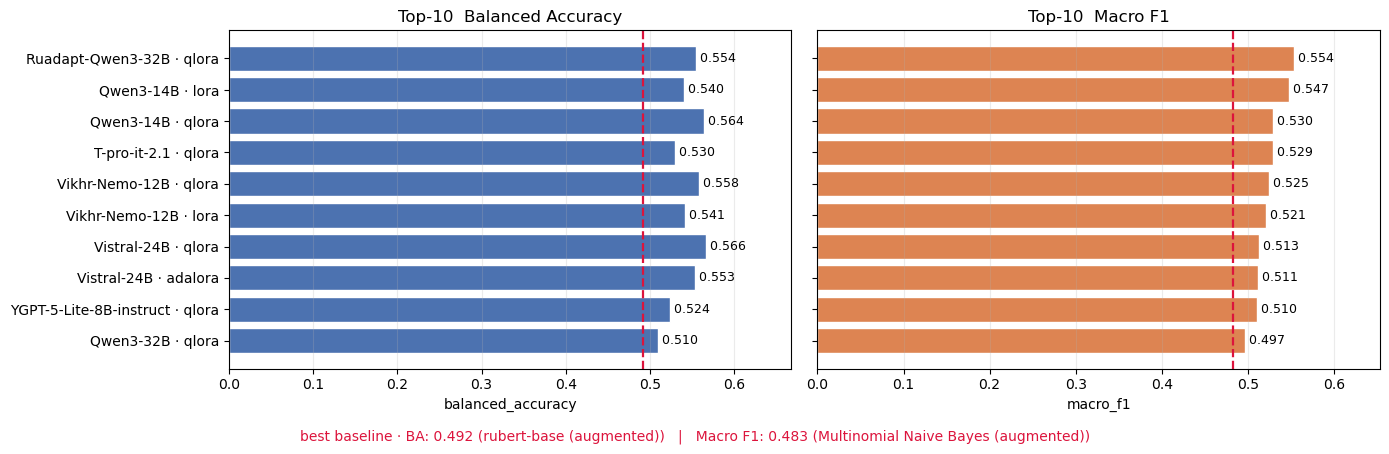

Лучший прирост над бейзлайном: BA +0.0737 (+7.37 п.п.), Macro F1 +0.0712 (+7.12 п.п.)


In [59]:
no_cw = df[~df['is_cw']].copy()
best_no_cw = (
    no_cw.sort_values('macro_f1', ascending=False)
         .drop_duplicates(subset=['model', 'method'], keep='first')
         .reset_index(drop=True)
)
top = best_no_cw.head(TOP_N).iloc[::-1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, max(4.5, 0.42 * len(top))), sharey=True)
specs = [
    ('balanced_accuracy', 'Balanced Accuracy', '#4C72B0', BASELINE_BA),
    ('macro_f1',          'Macro F1',          '#DD8452', BASELINE_F1),
]
for ax, (metric, title, color, base_val) in zip(axes, specs):
    ax.barh(top['mm'], top[metric], color=color, edgecolor='white')
    for i, v in enumerate(top[metric]):
        ax.text(v, i, f' {v:.3f}', va='center', fontsize=9)
    ax.axvline(base_val, color='crimson', linestyle='--', linewidth=1.6)
    ax.set_xlim(0, max(top[metric].max(), base_val) * 1.18)
    ax.set_xlabel(metric)
    ax.set_title(f'Top-{TOP_N}  {title}')
    ax.grid(axis='x', alpha=0.25)

fig.text(0.5, 0.01,
         f'best baseline · BA: {BASELINE_BA:.3f} ({BASELINE_BA_NAME})   |   '
         f'Macro F1: {BASELINE_F1:.3f} ({BASELINE_F1_NAME})',
         ha='center', fontsize=10, color='crimson')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

# Метрики в [0,1] → разница в п.п. = Δ × 100
lift_ba = top['balanced_accuracy'].max() - BASELINE_BA
lift_f1 = top['macro_f1'].max() - BASELINE_F1
print(f'Лучший прирост над бейзлайном: BA +{lift_ba:.4f} ({lift_ba*100:+.2f} п.п.), '
      f'Macro F1 +{lift_f1:.4f} ({lift_f1*100:+.2f} п.п.)')

## 2. Топ-N: не-CW vs CW (эффект class_weight)

Для каждой пары (model, method) из топ-N (по лучшему не-CW прогону) ищем соответствующий лучший CW-прогон и сравниваем обе метрики. Над барами — Δ относительно не-CW.

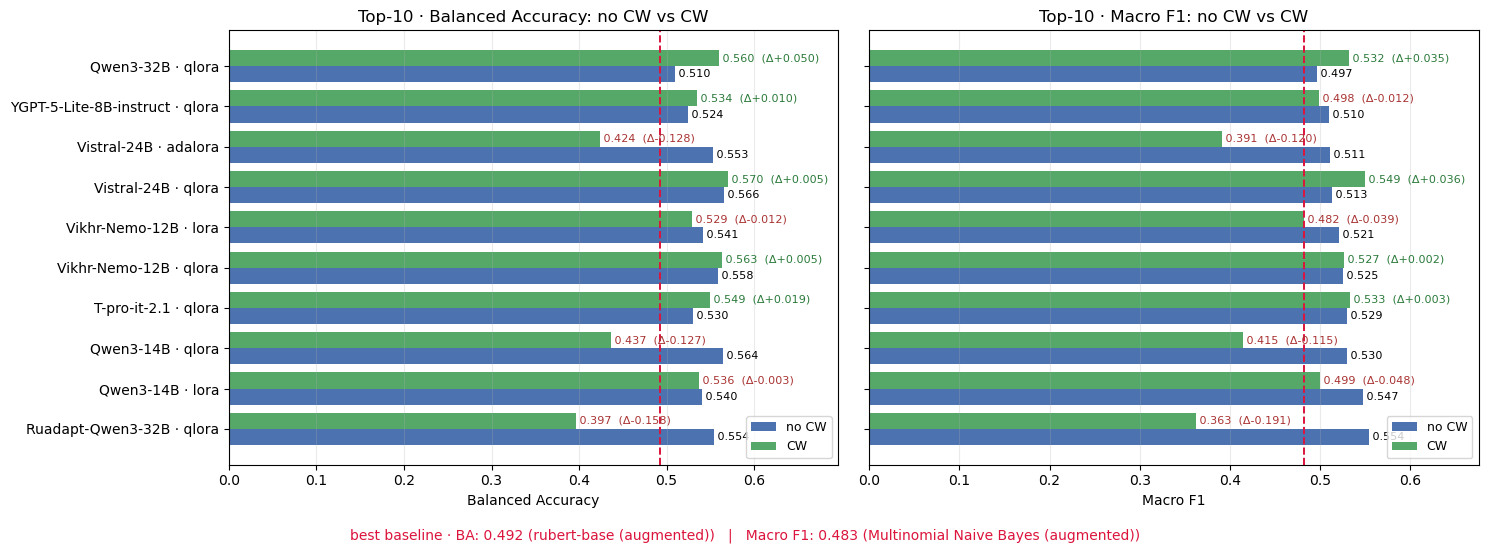

,run,BA noCW,BA CW,Δ BA,F1 noCW,F1 CW,Δ F1
0,Ruadapt-Qwen3-32B · qlora,0.5540,0.3965,-0.1575,0.5538,0.3627,-0.1911
1,Qwen3-14B · lora,0.5398,0.5365,-0.0033,0.5473,0.4993,-0.0480
2,Qwen3-14B · qlora,0.5638,0.4366,-0.1272,0.5297,0.4147,-0.1150
3,T-pro-it-2.1 · qlora,0.5299,0.5491,0.0192,0.5295,0.5327,0.0032
4,Vikhr-Nemo-12B · qlora,0.5583,0.5634,0.0051,0.5248,0.5269,0.0021
5,Vikhr-Nemo-12B · lora,0.5412,0.5291,-0.0121,0.5210,0.4821,-0.0389
6,Vistral-24B · qlora,0.5658,0.5704,0.0046,0.5131,0.5493,0.0362
7,Vistral-24B · adalora,0.5527,0.4242,-0.1285,0.5112,0.3911,-0.1201
8,YGPT-5-Lite-8B-instruct · qlora,0.5240,0.5343,0.0103,0.5101,0.4983,-0.0118
9,Qwen3-32B · qlora,0.5097,0.5601,0.0504,0.4970,0.5323,0.0353


In [55]:
# Лучший CW-прогон для каждой пары (model, method)
best_cw = (
    df[df['is_cw']]
      .sort_values('macro_f1', ascending=False)
      .drop_duplicates(subset=['model', 'method'], keep='first')
      .set_index(['model', 'method'])
)

# Та же выборка топ-N, что и выше: лучший no-CW per (model, method) → head(TOP_N)
pairs = best_no_cw.head(TOP_N).copy()
pairs['ba_cw']    = pairs.apply(lambda r: best_cw['balanced_accuracy'].get((r['model'], r['method']), np.nan), axis=1)
pairs['f1_cw']    = pairs.apply(lambda r: best_cw['macro_f1'].get((r['model'], r['method']), np.nan), axis=1)
pairs['delta_ba'] = pairs['ba_cw'] - pairs['balanced_accuracy']
pairs['delta_f1'] = pairs['f1_cw'] - pairs['macro_f1']

fig, axes = plt.subplots(1, 2, figsize=(15, max(5, 0.55 * len(pairs))), sharey=True)
labels = pairs['mm'].tolist()
y = np.arange(len(labels))
h = 0.4

for ax, (m_no, m_cw, title, base_val) in zip(axes, [
    ('balanced_accuracy', 'ba_cw', 'Balanced Accuracy', BASELINE_BA),
    ('macro_f1',          'f1_cw', 'Macro F1',          BASELINE_F1),
]):
    ax.barh(y - h/2, pairs[m_no], h, color='#4C72B0', label='no CW')
    ax.barh(y + h/2, pairs[m_cw], h, color='#55A868', label='CW')
    for i, (a, b) in enumerate(zip(pairs[m_no], pairs[m_cw])):
        if not np.isnan(a):
            ax.text(a, i - h/2, f' {a:.3f}', va='center', fontsize=8)
        if not np.isnan(b):
            delta = b - a if not np.isnan(a) else np.nan
            tag = f' {b:.3f}' + (f'  (Δ{delta:+.3f})' if not np.isnan(delta) else '')
            ax.text(b, i + h/2, tag, va='center', fontsize=8,
                    color='#2a7a3a' if (not np.isnan(delta) and delta >= 0) else '#a93232')
    ax.axvline(base_val, color='crimson', linestyle='--', linewidth=1.4)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    valid = np.concatenate([pairs[m_no].dropna().values, pairs[m_cw].dropna().values, [base_val]])
    ax.set_xlim(0, valid.max() * 1.22)
    ax.set_xlabel(title)
    ax.set_title(f'Top-{TOP_N} · {title}: no CW vs CW')
    ax.grid(axis='x', alpha=0.25)
    ax.legend(loc='lower right', fontsize=9)

fig.text(0.5, 0.01,
         f'best baseline · BA: {BASELINE_BA:.3f} ({BASELINE_BA_NAME})   |   '
         f'Macro F1: {BASELINE_F1:.3f} ({BASELINE_F1_NAME})',
         ha='center', fontsize=10, color='crimson')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

summary = pairs[['mm','balanced_accuracy','ba_cw','delta_ba','macro_f1','f1_cw','delta_f1']]
summary.columns = ['run', 'BA noCW', 'BA CW', 'Δ BA', 'F1 noCW', 'F1 CW', 'Δ F1']
summary.round(4)

## 3. Сравнение методов внутри каждой модели (без CW)

По одной панели на модель. Бары — методы, сгруппированные по обеим метрикам. Красная линия — бейзлайн по Macro F1.

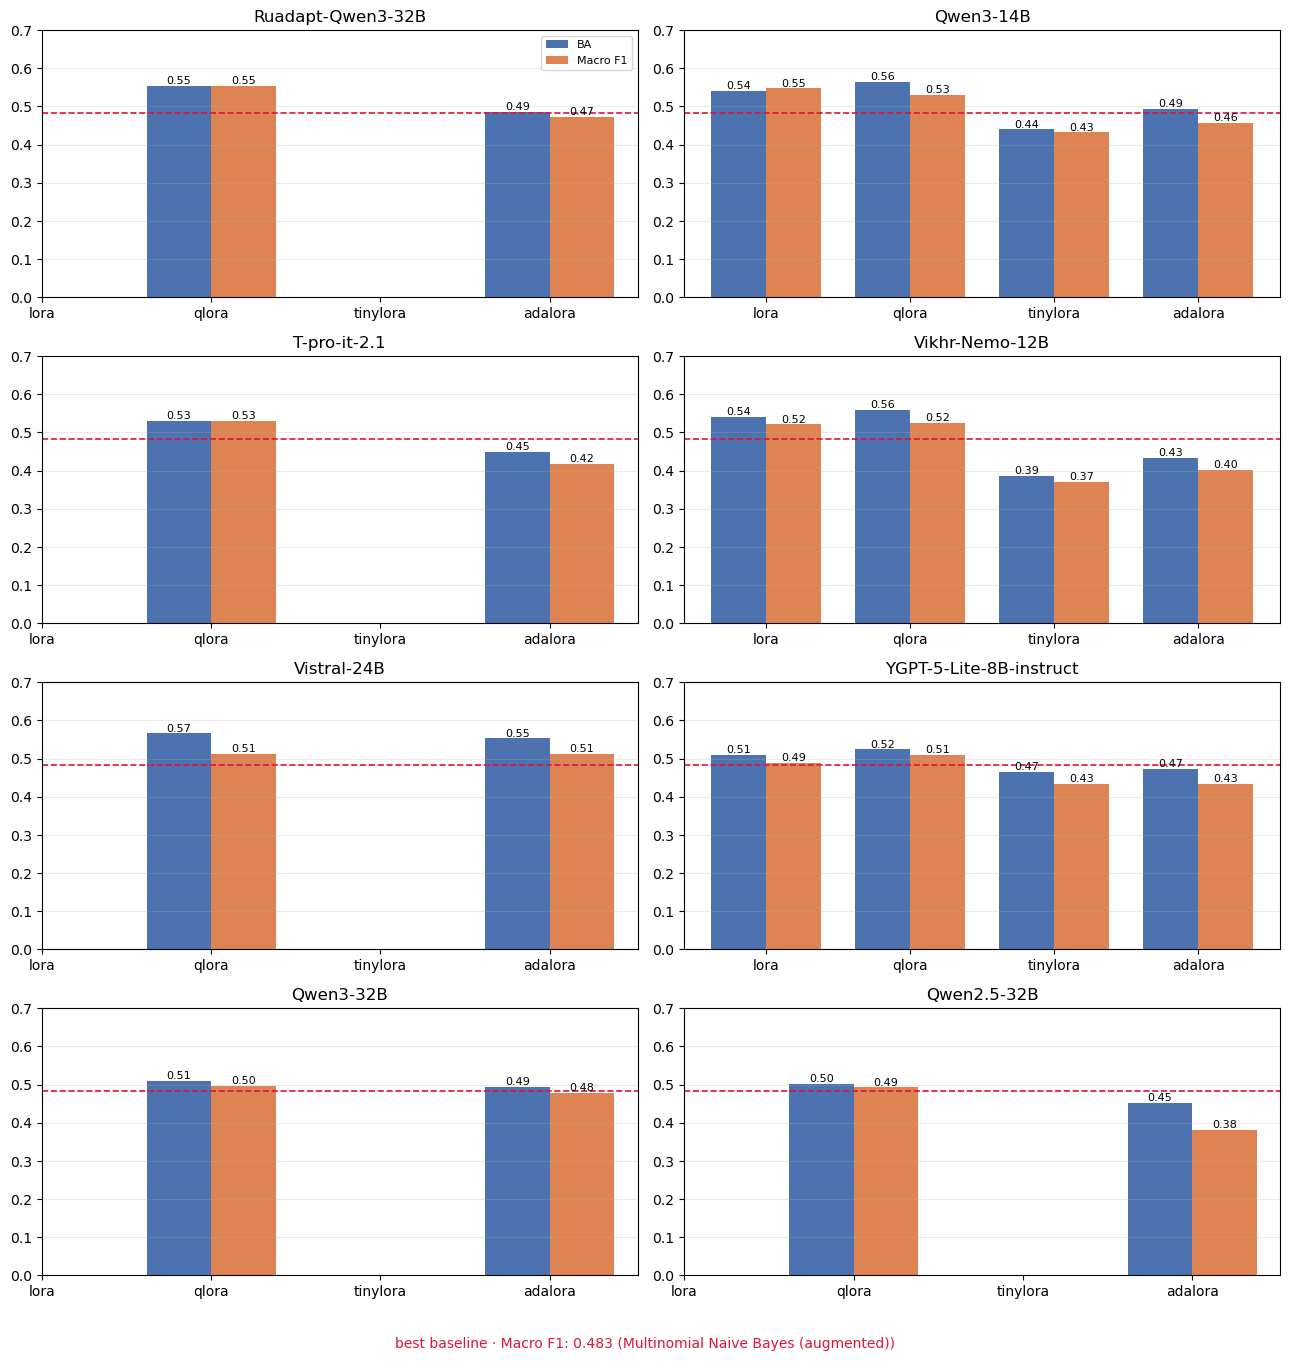

In [56]:
models = sorted(best_no_cw['model_short'].unique(),
                key=lambda m: -best_no_cw.loc[best_no_cw['model_short'] == m, 'macro_f1'].max())

n = len(models)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.4 * nrows), squeeze=False)

method_order = ['lora', 'qlora', 'tinylora', 'adalora']
x_pos = np.arange(len(method_order))
w = 0.38

for idx, model_name in enumerate(models):
    ax = axes[idx // ncols][idx % ncols]
    sub = best_no_cw[best_no_cw['model_short'] == model_name].set_index('method')
    ba_vals = [sub['balanced_accuracy'].get(m, np.nan) for m in method_order]
    f1_vals = [sub['macro_f1'].get(m, np.nan) for m in method_order]

    ax.bar(x_pos - w/2, ba_vals, w, color='#4C72B0', label='BA')
    ax.bar(x_pos + w/2, f1_vals, w, color='#DD8452', label='Macro F1')
    for i, (a, b) in enumerate(zip(ba_vals, f1_vals)):
        if not np.isnan(a):
            ax.text(i - w/2, a, f'{a:.2f}', ha='center', va='bottom', fontsize=8)
        if not np.isnan(b):
            ax.text(i + w/2, b, f'{b:.2f}', ha='center', va='bottom', fontsize=8)

    ax.axhline(BASELINE_F1, color='crimson', linestyle='--', linewidth=1.2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(method_order)
    ax.set_ylim(0, 0.7)
    ax.set_title(model_name)
    ax.grid(axis='y', alpha=0.25)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

fig.text(0.5, 0.005,
         f'best baseline · Macro F1: {BASELINE_F1:.3f} ({BASELINE_F1_NAME})',
         ha='center', fontsize=10, color='crimson')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 4. Дополнительный анализ

* **4.1** Разбивка по группам A/B/C для топ-N (где у модели «болит»).
* **4.2** Усреднённый эффект CW по методам — какой метод сильнее выигрывает от class_weight.

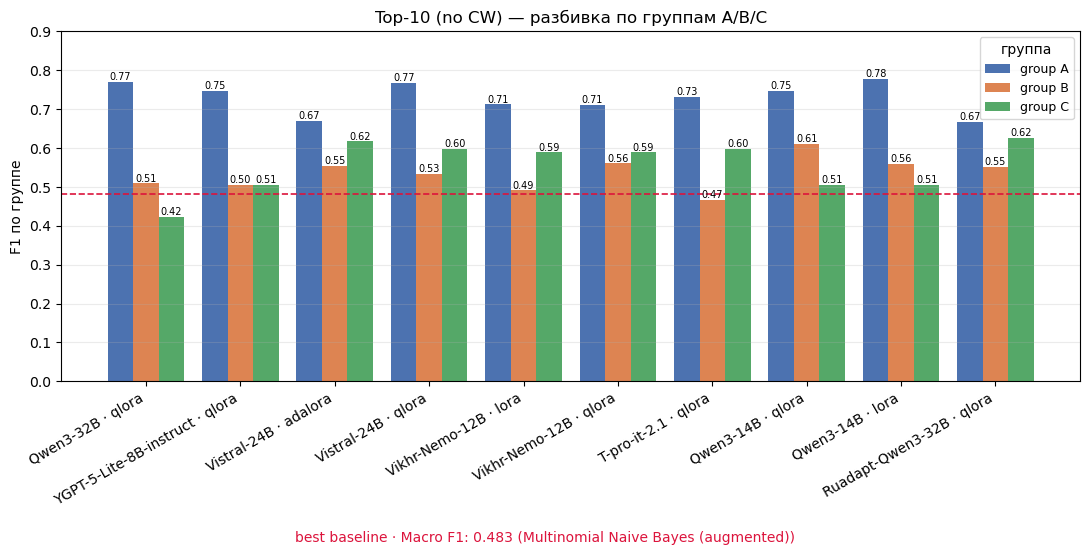

In [57]:
# 4.1 По группам A/B/C для топ-N (где модель сильна/слаба)
top = best_no_cw.head(TOP_N).iloc[::-1].copy()
groups = ['f1_group_A', 'f1_group_B', 'f1_group_C']
x_pos = np.arange(len(top))
w = 0.27

fig, ax = plt.subplots(figsize=(max(11, 0.85 * len(top)), 5.5))
colors = {'f1_group_A': '#4C72B0', 'f1_group_B': '#DD8452', 'f1_group_C': '#55A868'}
for i, g in enumerate(groups):
    offset = (i - 1) * w
    bars = ax.bar(x_pos + offset, top[g], w, color=colors[g], label=g.replace('f1_group_', 'group '))
    for b, v in zip(bars, top[g]):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}',
                ha='center', va='bottom', fontsize=7)

ax.axhline(BASELINE_F1, color='crimson', linestyle='--', linewidth=1.2)
ax.set_xticks(x_pos)
ax.set_xticklabels(top['mm'], rotation=30, ha='right')
ax.set_ylim(0, 0.9)
ax.set_ylabel('F1 по группе')
ax.set_title(f'Top-{TOP_N} (no CW) — разбивка по группам A/B/C')
ax.legend(loc='upper right', title='группа', fontsize=9)
ax.grid(axis='y', alpha=0.25)

fig.text(0.5, 0.005,
         f'best baseline · Macro F1: {BASELINE_F1:.3f} ({BASELINE_F1_NAME})',
         ha='center', fontsize=10, color='crimson')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

Δ (CW − noCW), усреднённый по моделям:
         delta_ba       delta_f1      
             mean count     mean count
method                                
adalora   -0.0592     8  -0.0480     8
lora       0.0076     3  -0.0200     3
qlora     -0.0170     8  -0.0263     8
tinylora   0.0121     3   0.0135     3


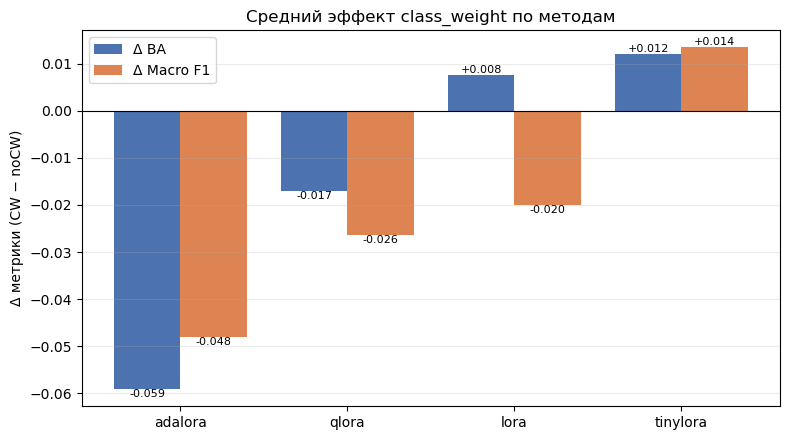

In [58]:
# 4.2 Усреднённый эффект CW по методам
no_cw_idx = best_no_cw.set_index(['model', 'method'])
cw_idx = best_cw
common = no_cw_idx.index.intersection(cw_idx.index)
diff = pd.DataFrame({
    'method': [m for _, m in common],
    'delta_ba': [cw_idx.loc[k, 'balanced_accuracy'] - no_cw_idx.loc[k, 'balanced_accuracy'] for k in common],
    'delta_f1': [cw_idx.loc[k, 'macro_f1'] - no_cw_idx.loc[k, 'macro_f1'] for k in common],
})
agg = diff.groupby('method').agg(['mean', 'count']).round(4)
print('Δ (CW − noCW), усреднённый по моделям:')
print(agg)

summary = diff.groupby('method')[['delta_ba', 'delta_f1']].mean().sort_values('delta_f1')
x = np.arange(len(summary))
w = 0.4
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, summary['delta_ba'], w, color='#4C72B0', label='Δ BA')
ax.bar(x + w/2, summary['delta_f1'], w, color='#DD8452', label='Δ Macro F1')
for i, (a, b) in enumerate(zip(summary['delta_ba'], summary['delta_f1'])):
    ax.text(i - w/2, a, f'{a:+.3f}', ha='center', va='bottom' if a >= 0 else 'top', fontsize=8)
    ax.text(i + w/2, b, f'{b:+.3f}', ha='center', va='bottom' if b >= 0 else 'top', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(summary.index)
ax.set_ylabel('Δ метрики (CW − noCW)')
ax.set_title('Средний эффект class_weight по методам')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()